In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from diffprivlib.models import LogisticRegression as DP_LogisticRegression
from sklearn.metrics import accuracy_score

# 1. データの準備
dataset = datasets.load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=0.2, random_state=42)

# 2. 通常のロジスティック回帰（比較用）
model_std = LogisticRegression(max_iter=10000)
model_std.fit(X_train, y_train)
acc_std = accuracy_score(y_test, model_std.predict(X_test))

# 3. 差分プライバシー対応ロジスティック回帰
# epsilon: プライバシー予算（小さいほど保護が強く、精度が落ちる）
# data_norm: 特徴量のL2ノルムの最大値（感度を決定するために必須）
epsilon = 1.0
data_norm = np.linalg.norm(X_train, axis=1).max()

model_dp = DP_LogisticRegression(epsilon=epsilon, data_norm=data_norm)
model_dp.fit(X_train, y_train)
acc_dp = accuracy_score(y_test, model_dp.predict(X_test))

# 4. 結果の出力
print(f"Standard Accuracy: {acc_std:.4f}")
print(f"DP Accuracy (epsilon={epsilon}): {acc_dp:.4f}")

Standard Accuracy: 0.9561
DP Accuracy (epsilon=1.0): 0.9035


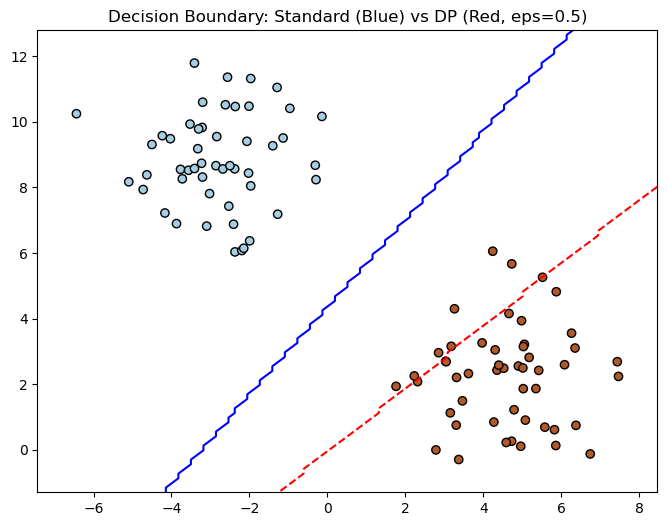

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from diffprivlib.models import LogisticRegression as DP_LogisticRegression

# 1. 2次元のダミーデータ生成（可視化のため）
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)

# 2. モデルの定義
# 標準的なロジスティック回帰
model_std = LogisticRegression()
model_std.fit(X, y)

# DPロジスティック回帰 (epsilon=0.5 と小さめに設定して差を強調)
epsilon = 0.5
data_norm = np.linalg.norm(X, axis=1).max()
model_dp = DP_LogisticRegression(epsilon=epsilon, data_norm=data_norm)
model_dp.fit(X, y)

# 3. 決定境界の描画関数の定義
def plot_boundary(model, X, label, color):
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100),
                         np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=[0.5], colors=color, linestyles='--' if 'DP' in label else '-')

# 4. 可視化
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plot_boundary(model_std, X, "Standard", "blue")
plot_boundary(model_dp, X, f"DP (eps={epsilon})", "red")
plt.title(f"Decision Boundary: Standard (Blue) vs DP (Red, eps={epsilon})")
plt.show()

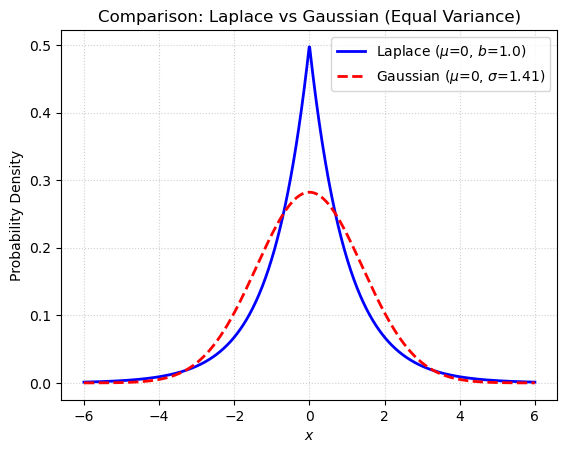

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. パラメータの設定
mu = 0     # 中心（平均）
b = 1.0    # ラプラス分布のスケールパラメータ
# 分散を等しくするため、ガウス分布の標準偏差 sigma を sqrt(2) * b に設定
sigma = np.sqrt(2) * b

# 2. x軸の範囲を設定
x = np.linspace(-6, 6, 1000)

# 3. 確率密度関数の計算
# ラプラス分布: f(x) = (1/2b) * exp(-|x-mu|/b)
laplace_pdf = (1 / (2 * b)) * np.exp(-np.abs(x - mu) / b)

# ガウス分布: f(x) = (1/sqrt(2*pi*sigma^2)) * exp(-0.5 * ((x-mu)/sigma)^2)
gaussian_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# 4. プロット
plt.plot(x, laplace_pdf, label=fr'Laplace ($\mu$={mu}, $b$={b})', color='blue', linewidth=2)
plt.plot(x, gaussian_pdf, label=fr'Gaussian ($\mu$={mu}, $\sigma$={sigma:.2f})', color='red', linestyle='--', linewidth=2)

plt.title('Comparison: Laplace vs Gaussian (Equal Variance)')
plt.xlabel('$x$')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 画像の保存
plt.savefig('laplace_gaussian_comparison.png')

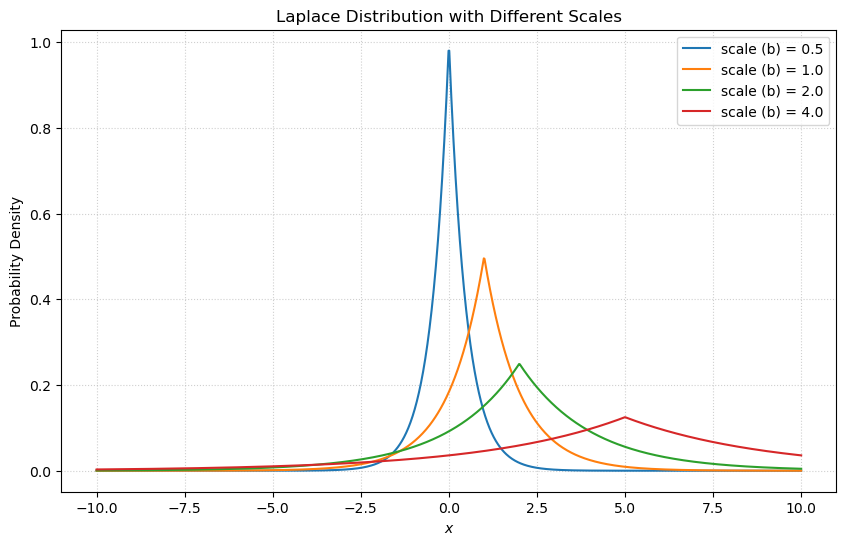

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. パラメータの設定
mus = [0, 1, 2, 5] 
scales = [0.5, 1.0, 2.0, 4.0]  # 異なるスケールパラメータ b
x = np.linspace(-10, 10, 1000)

# 2. プロット
plt.figure(figsize=(10, 6))

for b, mu in zip(scales, mus):
    # ラプラス分布の確率密度関数: f(x) = (1/2b) * exp(-|x-mu|/b)
    pdf = (1 / (2 * b)) * np.exp(-np.abs(x - mu) / b)
    plt.plot(x, pdf, label=f'scale (b) = {b}')

plt.title('Laplace Distribution with Different Scales')
plt.xlabel('$x$')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 3. 画像の保存
plt.savefig('laplace_scales_comparison.png')